# What is the most optimal skill to learn for Data Analysts?

### Methodology

1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [1]:
# Importing Libraries

import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset


# Loading Data

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [3]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [4]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by= 'count', ascending = False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

df_DA_skills

,skill_count,median_salary
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
couchbase,1,160515.0
chainer,1,100000.0
chef,1,85000.0


In [5]:
DA_job_count = len(df_DA_US)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
couchbase,1,160515.0,0.022989
chainer,1,100000.0,0.022989
chef,1,85000.0,0.022989


In [6]:
# Only keep skills appearing in more than 5% of DA job postings
# This removes niche skills that have unreliable salary medians

skill_percent = 5

min_skill_count = 10  # minimum postings for a reliable median salary

df_DA_skills_high_demand = df_DA_skills[
    (df_DA_skills['skill_percent'] > skill_percent) &
    (df_DA_skills['skill_count'] >= min_skill_count)
].copy()

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


### How to Read This Chart

- **X-axis** — how often this skill appears across DA job postings (demand)
- **Y-axis** — the median yearly salary for jobs requiring this skill (pay)
- **Top-right** — high demand AND high salary = most optimal to learn
- **Top-left** — high salary but rare = specialist/niche, fewer opportunities
- **Bottom-right** — very common but lower salary = foundational, expected by most employers

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


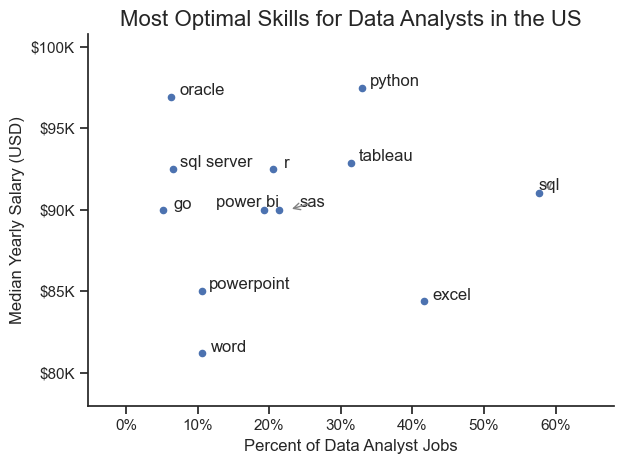

In [7]:
sns.set_theme(style='ticks')

df_DA_skills_high_demand.plot(kind='scatter',x = 'skill_percent', y = 'median_salary')
sns.despine()

# Prepare for text adjust
from adjustText import adjust_text

texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i]+1.5, df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to prevent overlap
adjust_text(texts, 
            arrowprops=dict(arrowstyle='->', color='gray'),
            expand_points=(2, 2),
            expand_text=(2, 2),
            force_text=10,
            force_points=1.5,
            lim=300)

# Set axis, labels, title, and legends
plt.title('Most Optimal Skills for Data Analysts in the US', fontsize=16)
plt.xlabel('Percent of Data Analyst Jobs', fontsize=12)
plt.ylabel('Median Yearly Salary (USD)', fontsize=12)

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and show plot
plt.margins(x=0.2, y=0.2)
plt.tight_layout()
plt.show()

In [8]:
df_technology = df_DA_US['job_type_skills'].copy()

# Remove NaN values & duplicates
df_technology = df_technology.dropna().drop_duplicates()

# Combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)    # Convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:      # if key already exists, add the value to the existing list
            technology_dict[key] += value 
        else:                           # if key does not exist, add key and value 
            technology_dict[key] = value

# Remove duplicate by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['sheets',
  'tableau',
  'sharepoint',
  'splunk',
  'dax',
  'sap',
  'spreadsheet',
  'ms access',
  'qlik',
  'looker',
  'excel',
  'sas',
  'alteryx',
  'ssrs',
  'visio',
  'word',
  'outlook',
  'powerpoint',
  'spss',
  'power bi',
  'cognos',
  'ssis',
  'microstrategy'],
 'programming': ['erlang',
  'mongodb',
  'julia',
  'golang',
  'fortran',
  'visual basic',
  'crystal',
  'vba',
  'r',
  'java',
  't-sql',
  'scala',
  'typescript',
  'swift',
  'python',
  'php',
  'no-sql',
  'c++',
  'bash',
  'c#',
  'solidity',
  'css',
  'sas',
  'assembly',
  'ruby',
  'matlab',
  'mongo',
  'vb.net',
  'sass',
  'html',
  'nosql',
  'c',
  'sql',
  'dart',
  'javascript',
  'rust',
  'shell',
  'powershell',
  'cobol',
  'go',
  'perl'],
 'cloud': ['databricks',
  'azure',
  'aws',
  'ibm cloud',
  'colocation',
  'snowflake',
  'watson',
  'bigquery',
  'firebase',
  'gcp',
  'oracle',
  'redshift',
  'vmware',
  'aurora'],
 'os': ['macos', 'linux', 'arch', '

In [9]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns = ['technology','skills'])

df_technology

,technology,skills
0,analyst_tools,"[sheets, tableau, sharepoint, splunk, dax, sap..."
1,programming,"[erlang, mongodb, julia, golang, fortran, visu..."
2,cloud,"[databricks, azure, aws, ibm cloud, colocation..."
3,os,"[macos, linux, arch, windows, unix]"
4,webframeworks,"[node, vue, angular, asp.net, django, drupal, ..."
5,other,"[flow, kubernetes, ansible, bitbucket, termina..."
6,databases,"[mysql, elasticsearch, mongodb, db2, cassandra..."
7,libraries,"[numpy, hugging face, cordova, tensorflow, ggp..."
8,async,"[monday.com, planner, wrike, clickup, airtable..."
9,sync,"[twilio, slack, unify, microsoft teams, zoom, ..."


In [10]:
df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,sheets
0,analyst_tools,tableau
0,analyst_tools,sharepoint
0,analyst_tools,splunk
0,analyst_tools,dax
...,...,...
9,sync,microsoft teams
9,sync,zoom
9,sync,wire
9,sync,webex


In [11]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on = 'job_skills', right_on = 'skills', how = 'left')

# Fill any skills that didn't match a technology category
df_plot['technology'] = df_plot['technology'].fillna('other')
df_plot['skills'] = df_plot['skills'].fillna(df_plot.index.to_series())

df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


4 [0.46471328 0.44917126]
5 [ 0.88055264 -0.65935948]


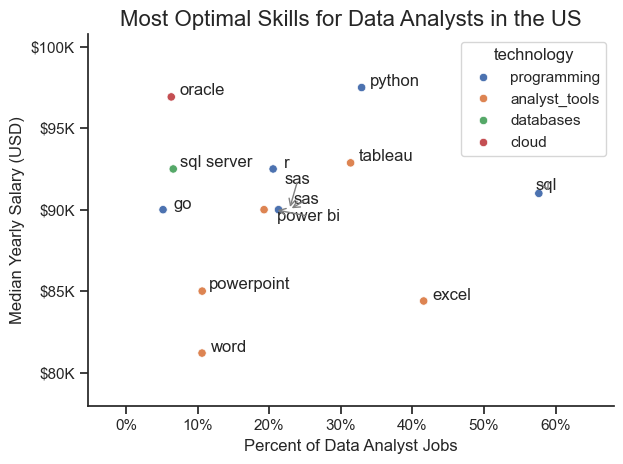

In [12]:
sns.set_theme(style='ticks')

sns.scatterplot(data = df_plot,x = 'skill_percent', y = 'median_salary', hue = 'technology')
sns.despine()

# Prepare to adjust text labels

from adjustText import adjust_text

texts = []
for i in range(len(df_plot)):
    texts.append(
        plt.text(
            df_plot['skill_percent'].iloc[i]+1.5, 
            df_plot['median_salary'].iloc[i],
            df_plot['skills'].iloc[i]
            )
        )

# Adjust text to avoid overlap

adjust_text(texts, 
            arrowprops=dict(arrowstyle='->', color='gray'), 
            expand_points=(2, 2),
            expand_text=(2, 2),
            force_text=10,
            force_points=1.5,
            lim=300)

# Set axis labels, title, and legends

plt.title('Most Optimal Skills for Data Analysts in the US', fontsize=16)
plt.xlabel('Percent of Data Analyst Jobs', fontsize=12)
plt.ylabel('Median Yearly Salary (USD)', fontsize=12) 

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and show plot
plt.margins(x=0.2, y=0.2)   
plt.tight_layout()
plt.show()